In [2]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

# reload your data — each notebook should be self contained
df_deaths = pd.read_csv('../data/Deaths_1x1.txt', skiprows=2, sep=r'\s+')
df_deaths['Age'] = df_deaths['Age'].replace('110+', 110).astype(int)

df_exposure = pd.read_csv('../data/Exposures_1x1.txt', skiprows=2, sep=r'\s+')
df_exposure['Age'] = df_exposure['Age'].replace('110+', 110).astype(int)

df = df_deaths.merge(df_exposure, on=['Year', 'Age'], suffixes=('_deaths', '_exp'))
df['mx_total'] = df['Total_deaths'] / df['Total_exp']
df['mx_male'] = df['Male_deaths'] / df['Male_exp']
df['mx_female'] = df['Female_deaths'] / df['Female_exp']

print("Data loaded:", df.shape)

Data loaded: (11211, 11)


In [3]:
df_lc = df[(df['Age'] <= 100)].copy()

# create matrix: rows = ages, columns = years
matrix = df_lc.pivot(index='Age', columns='Year', values='mx_total')

# log transform — Lee-Carter works on log mortality rates
log_mx = np.log(matrix.values)

ages = matrix.index.values
years = matrix.columns.values

print("Matrix shape (ages x years):", log_mx.shape)
print("Ages:", ages[0], "to", ages[-1])
print("Years:", years[0], "to", years[-1])

Matrix shape (ages x years): (101, 101)
Ages: 0 to 100
Years: 1921 to 2021


In [4]:
# alpha_x is the average log mortality rate at each age across all years
alpha_x = log_mx.mean(axis=1)

# centre the matrix by subtracting alpha
centred = log_mx - alpha_x[:, np.newaxis]

# SVD decomposition
U, S, Vt = np.linalg.svd(centred)

# take only first singular value/vector (rank-1 approximation)
b_raw = U[:, 0]      # age component (beta_x before normalisation)
k_raw = Vt[0, :]     # time component (kappa_t before normalisation)
s1 = S[0]            # first singular value

# normalise so beta_x sums to 1
beta_x = b_raw / b_raw.sum()
kappa_t = k_raw * s1 * b_raw.sum()

print("beta_x shape:", beta_x.shape)
print("kappa_t shape:", kappa_t.shape)

beta_x shape: (101,)
kappa_t shape: (101,)


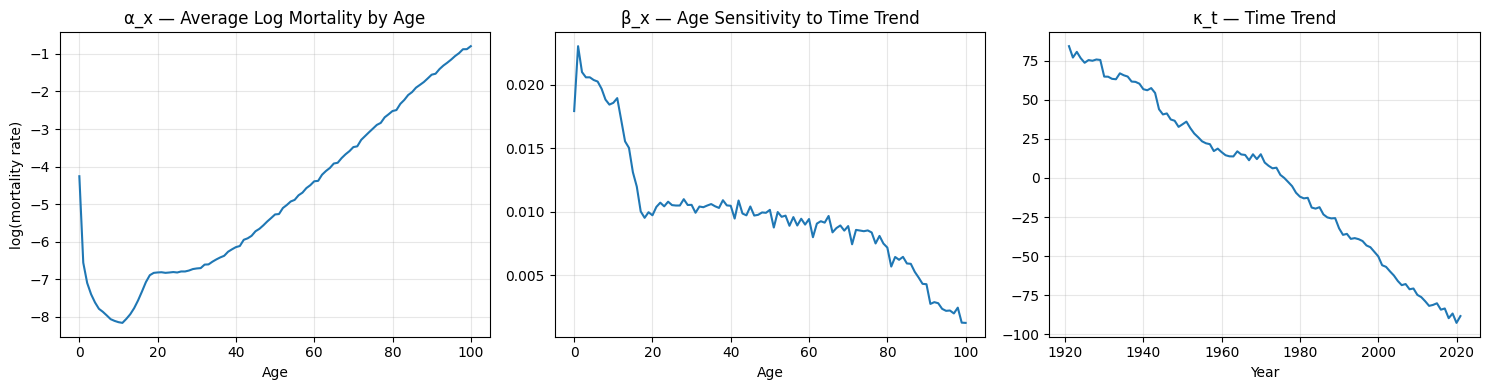

In [5]:
fig, axes = plt.subplots(1, 3, figsize=(15, 4))

# alpha_x — average log mortality by age
axes[0].plot(ages, alpha_x)
axes[0].set_title('α_x — Average Log Mortality by Age')
axes[0].set_xlabel('Age')
axes[0].set_ylabel('log(mortality rate)')
axes[0].grid(True, alpha=0.3)

# beta_x — sensitivity of each age to time trend
axes[1].plot(ages, beta_x)
axes[1].set_title('β_x — Age Sensitivity to Time Trend')
axes[1].set_xlabel('Age')
axes[1].grid(True, alpha=0.3)

# kappa_t — time trend
axes[2].plot(years, kappa_t)
axes[2].set_title('κ_t — Time Trend')
axes[2].set_xlabel('Year')
axes[2].grid(True, alpha=0.3)

plt.tight_layout()
plt.show()

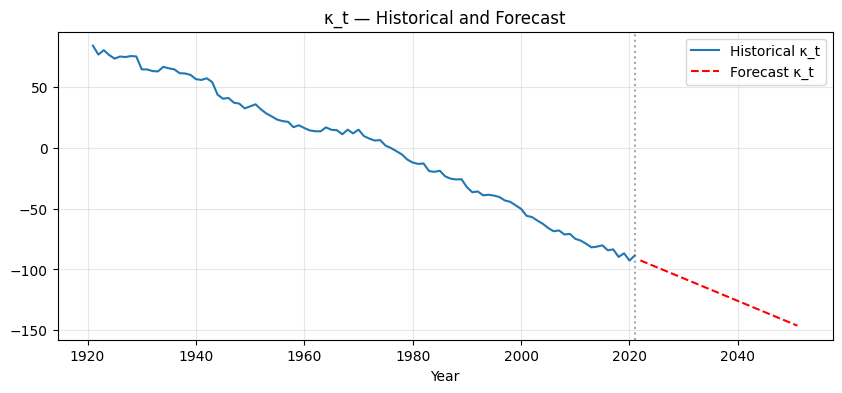

In [ ]:
from sklearn.linear_model import LinearRegression

# fitting a simple linear trend to kappa_t for forecasting
post1950 = years >= 1950
kappa_hist = kappa_t[post1950]
years_hist = years[post1950].reshape(-1, 1)

model = LinearRegression()
model.fit(years_hist, kappa_hist)

# forecast 30 years ahead
forecast_years = np.arange(2022, 2052).reshape(-1, 1)
kappa_forecast = model.predict(forecast_years)

# plot historical + forecast kappa
plt.figure(figsize=(10, 4))
plt.plot(years, kappa_t, label='Historical κ_t')
plt.plot(forecast_years, kappa_forecast, 'r--', label='Forecast κ_t')
plt.axvline(2021, color='grey', linestyle=':', alpha=0.7)
plt.xlabel('Year')
plt.title('κ_t — Historical and Forecast')
plt.legend()
plt.grid(True, alpha=0.3)
plt.show()

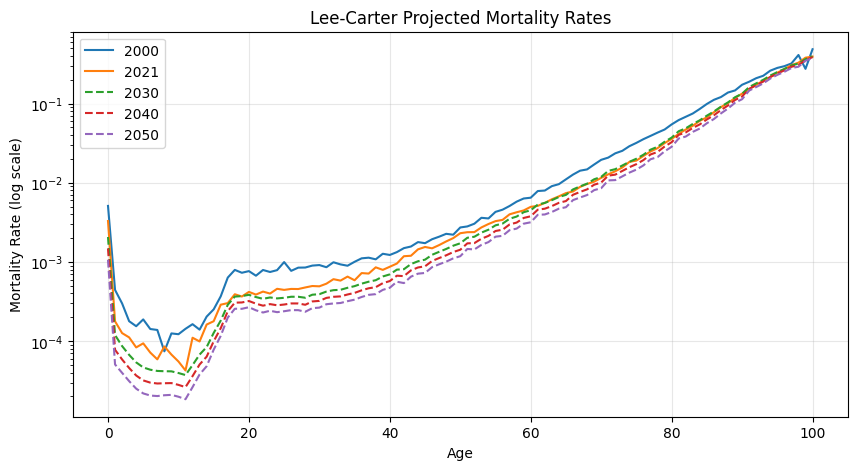

In [7]:
# project mortality rates for forecast years using Lee-Carter formula

forecast_years_flat = forecast_years.flatten()

# build projected log mortality matrix (ages x forecast years)
projected_log_mx = alpha_x[:, np.newaxis] + beta_x[:, np.newaxis] * kappa_forecast[np.newaxis, :]
projected_mx = np.exp(projected_log_mx)

# plot projected mortality curves for selected years
plt.figure(figsize=(10, 5))
plot_years = [2000, 2021, 2030, 2040, 2050]

for yr in plot_years:
    if yr <= 2021:
        idx = np.where(years == yr)[0][0]
        mx_vals = np.exp(log_mx[:, idx])
        linestyle = '-'
    else:
        idx = np.where(forecast_years_flat == yr)[0][0]
        mx_vals = projected_mx[:, idx]
        linestyle = '--'
    plt.plot(ages, mx_vals, linestyle=linestyle, label=str(yr))

plt.yscale('log')
plt.xlabel('Age')
plt.ylabel('Mortality Rate (log scale)')
plt.title('Lee-Carter Projected Mortality Rates')
plt.legend()
plt.grid(True, alpha=0.3)
plt.show()

In [8]:
# reconstructing fitted values from Lee-Carter
fitted_log_mx = alpha_x[:, np.newaxis] + beta_x[:, np.newaxis] * kappa_t[np.newaxis, :]
fitted_mx = np.exp(fitted_log_mx)
actual_mx = matrix.values

# calculate mean absolute error and RMSE on log scale
from sklearn.metrics import mean_squared_error, mean_absolute_error

actual_log = log_mx.flatten()
fitted_log = fitted_log_mx.flatten()

mae = mean_absolute_error(actual_log, fitted_log)
rmse = np.sqrt(mean_squared_error(actual_log, fitted_log))

print(f"Lee-Carter In-Sample Performance (log scale):")
print(f"MAE:  {mae:.4f}")
print(f"RMSE: {rmse:.4f}")

Lee-Carter In-Sample Performance (log scale):
MAE:  0.1091
RMSE: 0.1356


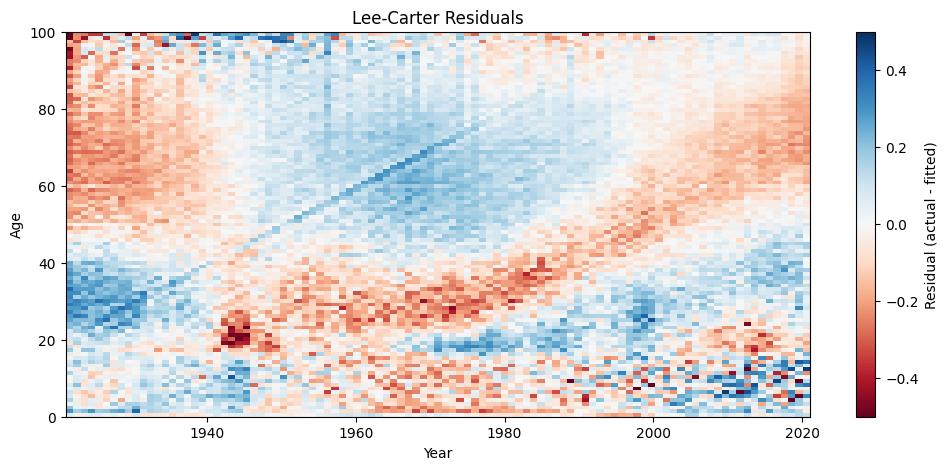

In [9]:
residuals = log_mx - fitted_log_mx

plt.figure(figsize=(12, 5))

# residuals as heatmap
plt.imshow(residuals, aspect='auto', origin='lower',
           extent=[years[0], years[-1], 0, 100],
           cmap='RdBu', vmin=-0.5, vmax=0.5)
plt.colorbar(label='Residual (actual - fitted)')
plt.xlabel('Year')
plt.ylabel('Age')
plt.title('Lee-Carter Residuals')
plt.show()